## ทด

### Check Evaluation on map

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np

xai_method = "rollout"

curve_dir = Path(f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/{xai_method}/attention_mask")

rows = []

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    rows.append(data)

Collection = pd.DataFrame(rows)
#print(Collection[Collection.columns[0]])
print(Collection.head(1).confidences)
print(Collection.head(1).auc)


0    [[0.032363124, 0.00015194918, 0.967485], [0.02...
Name: confidences, dtype: object
0    0.856515
Name: auc, dtype: float64


In [20]:
print(str(Collection.iloc[1, 0]))
print(str(Collection.iloc[1, 1]))
print(str(Collection.iloc[1, 2]))



[0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[[[ 5.7199526  -3.3632581  -1.5908791 ]]

 [[ 5.6409426  -3.3842282  -1.4943811 ]]

 [[ 5.586882   -3.4424956  -1.4170905 ]]

 [[ 5.595512   -3.5477839  -1.3314929 ]]

 [[ 5.5419464  -3.4575315  -1.3719033 ]]

 [[ 5.533934   -3.4026115  -1.4087132 ]]

 [[ 5.559961   -3.3169034  -1.5436081 ]]

 [[ 5.491813   -3.4466338  -1.3254489 ]]

 [[ 5.5879107  -3.2816741  -1.5924301 ]]

 [[ 5.5520306  -3.4572659  -1.38107   ]]

 [[ 5.572043   -3.3621492  -1.4783244 ]]

 [[ 5.5618196  -3.4533567  -1.3453218 ]]

 [[ 5.4289126  -3.1300652  -1.5760547 ]]

 [[ 5.224383   -2.8643126  -1.6829027 ]]

 [[ 5.0378985  -3.0708094  -1.385919  ]]

 [[ 4.905268   -3.009429   -1.4221802 ]]

 [[ 4.461562   -3.1940918  -0.9363365 ]]

 [[ 4.0256257  -3.5536952  -0.13461146]]

 [[ 3.0928268  -3.6014812   0.63730645]]

 [[ 1.7222769  -2.821164    0.9922456 ]]

 [[ 1.8818225  -2.8681397   1.4476635 ]]]
[[9.992187

See Data in Saliency

In [21]:
import numpy as np

xai_method = "slice_weighted_rollout"

file_path = f"/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/saliency_results/{xai_method}/class_2/npy/08FEB48B_right_importance.npy"

data = np.load(file_path)

print("Type:", type(data))
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print(data[1][1][0:14])
print("Data:", data)



Type: <class 'numpy.ndarray'>
Shape: (32, 224, 224)
Dtype: float32
[0.00463444 0.00463444 0.00463444 0.00463444 0.00463444 0.00463444
 0.00463444 0.00463598 0.00463906 0.00464215 0.00464523 0.00464832
 0.0046514  0.00465449]
Data: [[[0.00647341 0.00647341 0.00647341 ... 0.00596182 0.00596182 0.00596182]
  [0.00647341 0.00647341 0.00647341 ... 0.00596182 0.00596182 0.00596182]
  [0.00647341 0.00647341 0.00647341 ... 0.00596182 0.00596182 0.00596182]
  ...
  [0.00505686 0.00505686 0.00505686 ... 0.00690714 0.00690714 0.00690714]
  [0.00505686 0.00505686 0.00505686 ... 0.00690714 0.00690714 0.00690714]
  [0.00505686 0.00505686 0.00505686 ... 0.00690714 0.00690714 0.00690714]]

 [[0.00463444 0.00463444 0.00463444 ... 0.00425836 0.00425836 0.00425836]
  [0.00463444 0.00463444 0.00463444 ... 0.00425836 0.00425836 0.00425836]
  [0.00463444 0.00463444 0.00463444 ... 0.00425836 0.00425836 0.00425836]
  ...
  [0.00310203 0.00310203 0.00310203 ... 0.00502022 0.00502022 0.00502022]
  [0.00310203 0

In [22]:
print(data.shape)
print(data.dtype)
print(data.min(), data.max())

(32, 224, 224)
float32
0.0 0.9999989


#### Show a single slice

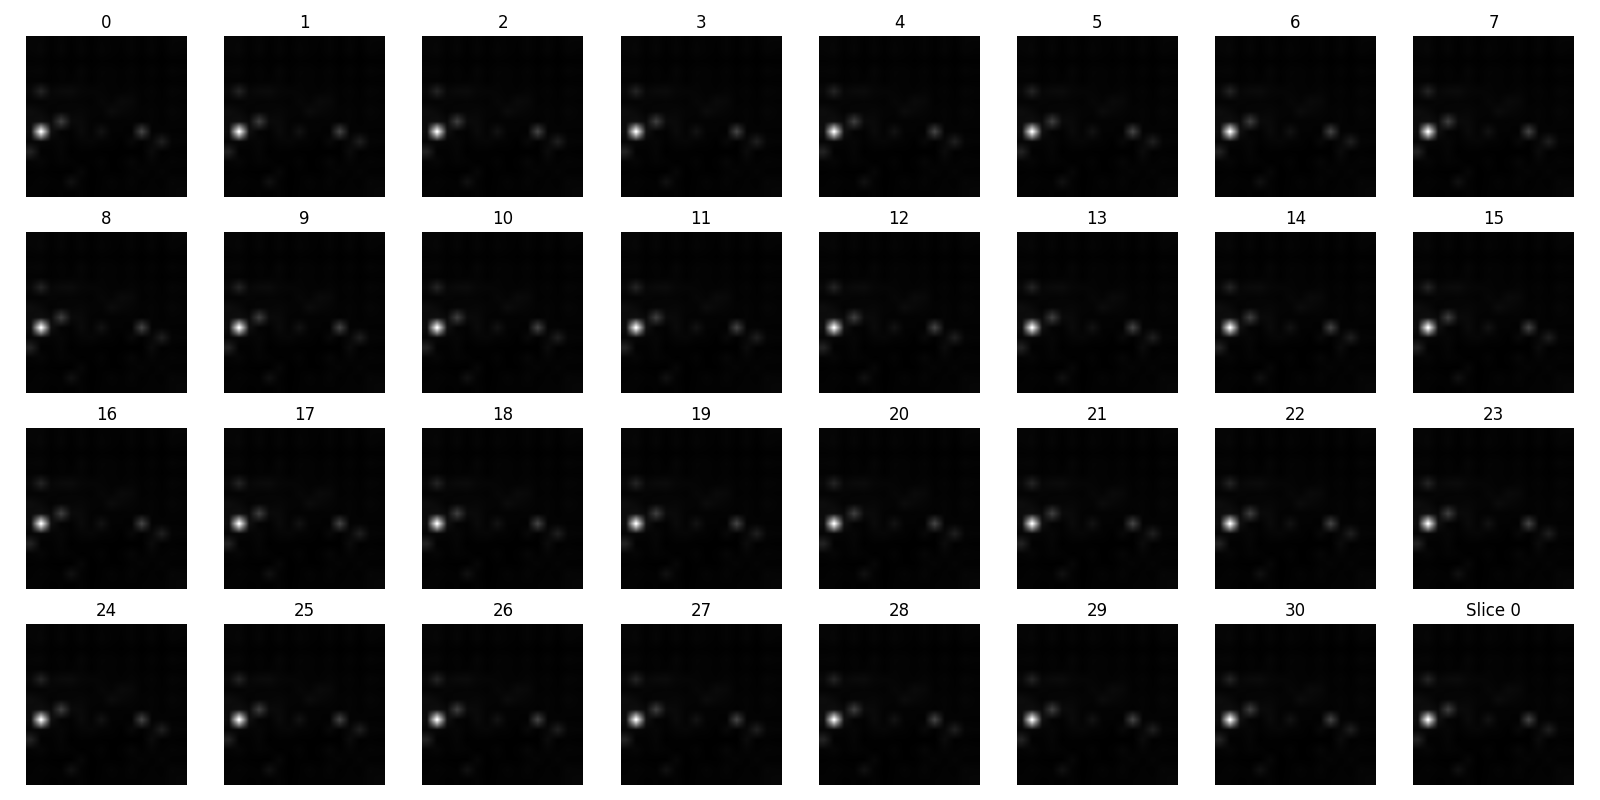

In [23]:
import matplotlib.pyplot as plt

plt.imshow(data[0], cmap="gray")
plt.title("Slice 0")
plt.axis("off")
plt.show()

Scroll through slices

In [12]:
%matplotlib widget

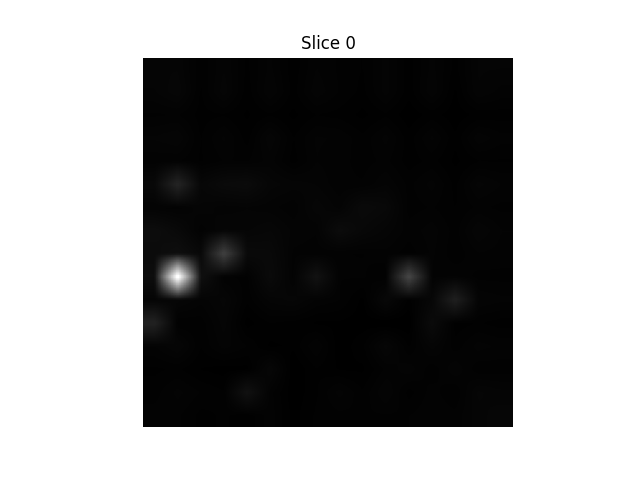

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

idx = 0
im = ax.imshow(data[idx], cmap="gray")
ax.set_title(f"Slice {idx}")
ax.axis("off")

def on_key(event):
    global idx
    if event.key == "right":
        idx = (idx + 1) % data.shape[0]
    elif event.key == "left":
        idx = (idx - 1) % data.shape[0]

    im.set_data(data[idx])
    ax.set_title(f"Slice {idx}")
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("key_press_event", on_key)
plt.show()

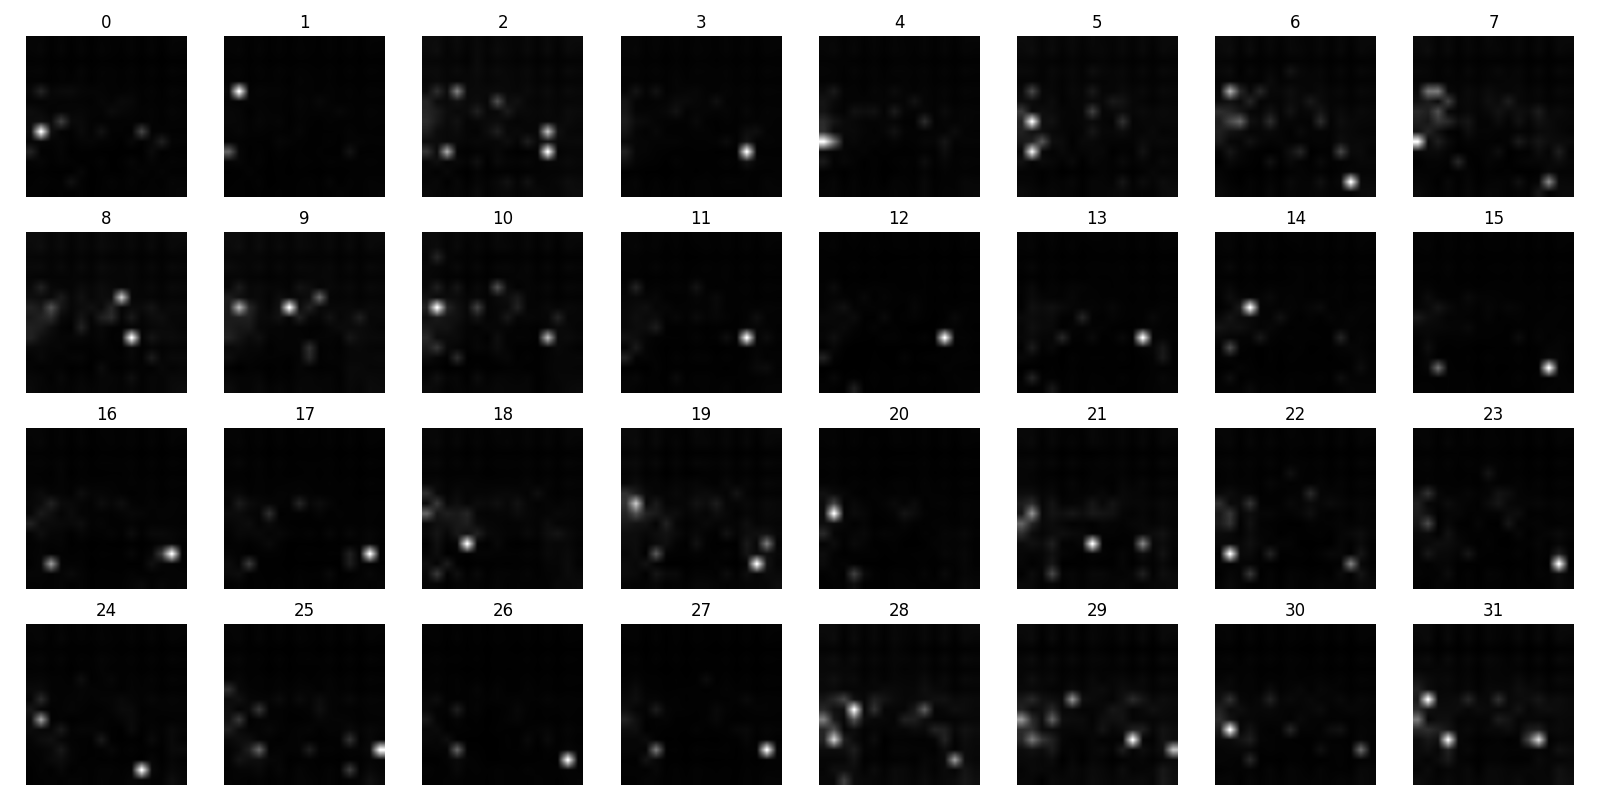

In [25]:
import matplotlib.pyplot as plt
import math

n = data.shape[0]
cols = 8
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 2*rows))

for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(data[i], cmap="gray")
        ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

Are all slices exactly the same?

In [16]:
import numpy as np

all_equal = np.all(data == data[0])
print("All slices identical:", all_equal)

All slices identical: True


Find which slices differ

In [17]:
ref = data[0]
diff_slices = [i for i in range(data.shape[0]) if not np.allclose(data[i], ref, atol=1e-6)]
print("Different slices:", diff_slices)

Different slices: []
